# Skin Disease Classification (VGG19)

### **Colab / Local Environment Setup**
This notebook auto-detects the environment and configures paths accordingly.

- **Google Colab**: Upload your `train` and `test` folders to your Google Drive under `My Drive/Grad proj/`, then the notebook will mount Drive automatically.
- **Local (Windows)**: Ensure your `train` and `test` folders are at `D:\Grad proj\train` and `D:\Grad proj\test`, OR in the same directory as this notebook.

## 1. Environment Detection & Path Setup

In [5]:
import os
# ============================================================
# ENVIRONMENT DETECTION - works on Colab, Local Windows, Linux
# ============================================================

TRAIN_DIR = None
TEST_DIR = None

# --- Option 1: Google Colab ---
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Check if data is already at /content/train (e.g. uploaded directly)
    if os.path.exists('/content/train'):
        TRAIN_DIR = '/content/train'
        TEST_DIR = '/content/test'
        print('[INFO] Running on Colab - data found at /content/train')
    else:
        # Skip mounting Google Drive as data is expected to come from Kaggle download
        print('[INFO] Skipping Google Drive mount as Kaggle data is used.')

# --- Option 2: Local Windows ---
if TRAIN_DIR is None and os.path.exists(r'D:\Grad proj\train'):
    TRAIN_DIR = r'D:\Grad proj\train'
    TEST_DIR = r'D:\Grad proj\test'
    print('[INFO] Running on Local Windows Environment')

# --- Option 3: Relative to current working directory ---
if TRAIN_DIR is None:
    cwd_train = os.path.join(os.getcwd(), 'train')
    if os.path.exists(cwd_train):
        TRAIN_DIR = cwd_train
        TEST_DIR = os.path.join(os.getcwd(), 'test')
        print(f'[INFO] Found data relative to working directory: {os.getcwd()}')

# --- Option 4: Relative path (last resort) ---
if TRAIN_DIR is None:
    if os.path.exists('train'):
        TRAIN_DIR = 'train'
        TEST_DIR = 'test'
        print('[INFO] Using relative train/test paths')

# The final check for FileNotFoundError is removed here.
# TRAIN_DIR and TEST_DIR will be set by the Kaggle download step (cell 921ad634).

# print(f'\nTrain Dir: {TRAIN_DIR}') # These lines will now execute after Kaggle download
# print(f'Test Dir:  {TEST_DIR}')   # in cell 921ad634.
# if TRAIN_DIR and os.path.exists(TRAIN_DIR):
#     print(f'Train folders: {len(os.listdir(TRAIN_DIR))}')
# else:
#     print('Train directory not yet set or found.')
# if TEST_DIR and os.path.exists(TEST_DIR):
#     print(f'Test folders:  {len(os.listdir(TEST_DIR))}')
# else:
#     print('Test directory not yet set or found.')

[INFO] Skipping Google Drive mount as Kaggle data is used.


## Resources

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubhamgoel27/dermnet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dermnet' dataset.
Path to dataset files: /kaggle/input/dermnet


### Update Data Directories to use Kaggle Dataset

Now that the Kaggle dataset is downloaded, we will update the `TRAIN_DIR` and `TEST_DIR` variables to point to the `train` and `test` subdirectories within the downloaded path. This ensures that subsequent data loading and processing steps use the Kaggle data.

In [7]:
import os

# Assuming the downloaded dataset has 'train' and 'test' subdirectories
TRAIN_DIR = os.path.join(path, 'train')
TEST_DIR = os.path.join(path, 'test')

print(f'Updated Train Dir: {TRAIN_DIR}')
print(f'Updated Test Dir:  {TEST_DIR}')

# Verify if the directories exist
if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Train directory not found at {TRAIN_DIR}")
if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Test directory not found at {TEST_DIR}")

print(f'Train folders: {len(os.listdir(TRAIN_DIR))}')
print(f'Test folders:  {len(os.listdir(TEST_DIR))}')

Updated Train Dir: /kaggle/input/dermnet/train
Updated Test Dir:  /kaggle/input/dermnet/test
Train folders: 23
Test folders:  23


## 2. Robust Data Indexing

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
FOLDER_MAP = {
    'Acne': ['Acne and Rosacea Photos'],
    'Eczema': ['Eczema Photos', 'Atopic Dermatitis Photos'],
    'Psoriasis': ['Psoriasis pictures Lichen Planus and related diseases'],
    'Fungal': ['Tinea Ringworm Candidiasis and other Fungal Infections'],
    'Melanoma': ['Melanoma Skin Cancer Nevi and Moles'],
    'Vitiligo': ['Light Diseases and Disorders of Pigmentation']
}

def build_df(base_dir, mapping):
    data = []
    found_on_disk = os.listdir(base_dir)

    for label, folders in mapping.items():
        for folder in folders:
            # Try case-insensitive matching for Linux/Colab robustness
            match = next((f for f in found_on_disk if f.lower() == folder.lower()), None)

            if match:
                path = os.path.join(base_dir, match)
                imgs = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                if imgs:
                    print(f"  [LOADED] {label}: {len(imgs)} images from '{match}'")
                    for img in imgs:
                        data.append({'filename': os.path.join(match, img), 'class': label})
            else:
                print(f"  [MISSING] {folder}")

    return pd.DataFrame(data, columns=['filename', 'class'])

print("Indexing images...")
df_train_full = build_df(TRAIN_DIR, FOLDER_MAP)
df_test = build_df(TEST_DIR, FOLDER_MAP)

if df_train_full.empty:
    print("\nAvailable Folders in Train Dir:", os.listdir(TRAIN_DIR))
    raise ValueError("No images found. Check folder names against the list above.")

# Split 80/20
df_train, df_val = train_test_split(df_train_full, test_size=0.2, stratify=df_train_full['class'], random_state=42)
print(f"\nDataset Stats: Train={len(df_train)}, Val={len(df_val)}, Test={len(df_test)}")

Indexing images...
  [LOADED] Acne: 840 images from 'Acne and Rosacea Photos'
  [LOADED] Eczema: 1235 images from 'Eczema Photos'
  [LOADED] Eczema: 489 images from 'Atopic Dermatitis Photos'
  [LOADED] Psoriasis: 1405 images from 'Psoriasis pictures Lichen Planus and related diseases'
  [LOADED] Fungal: 1300 images from 'Tinea Ringworm Candidiasis and other Fungal Infections'
  [LOADED] Melanoma: 463 images from 'Melanoma Skin Cancer Nevi and Moles'
  [LOADED] Vitiligo: 568 images from 'Light Diseases and Disorders of Pigmentation'
  [LOADED] Acne: 312 images from 'Acne and Rosacea Photos'
  [LOADED] Eczema: 309 images from 'Eczema Photos'
  [LOADED] Eczema: 123 images from 'Atopic Dermatitis Photos'
  [LOADED] Psoriasis: 352 images from 'Psoriasis pictures Lichen Planus and related diseases'
  [LOADED] Fungal: 325 images from 'Tinea Ringworm Candidiasis and other Fungal Infections'
  [LOADED] Melanoma: 116 images from 'Melanoma Skin Cancer Nevi and Moles'
  [LOADED] Vitiligo: 143 ima

## 4. Exploratory Data Analysis (EDA)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Define class names here as it's needed for EDA before model training
class_names = sorted(df_train_full['class'].unique())
print(f"Detected Classes: {class_names}")

Detected Classes: ['Acne', 'Eczema', 'Fungal', 'Melanoma', 'Psoriasis', 'Vitiligo']


### Class Distribution

/tmp/ipykernel_9124/1510794164.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df_train_full, order=class_names, palette='viridis')
/tmp/ipykernel_9124/1510794164.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df_train, order=class_names, palette='viridis')
/tmp/ipykernel_9124/1510794164.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df_val, order=class_names, palette='viridis')
/tmp/ipykernel_9124/1510794164.py:23: FutureWarning: 

Passing `palette` without assigning `hue

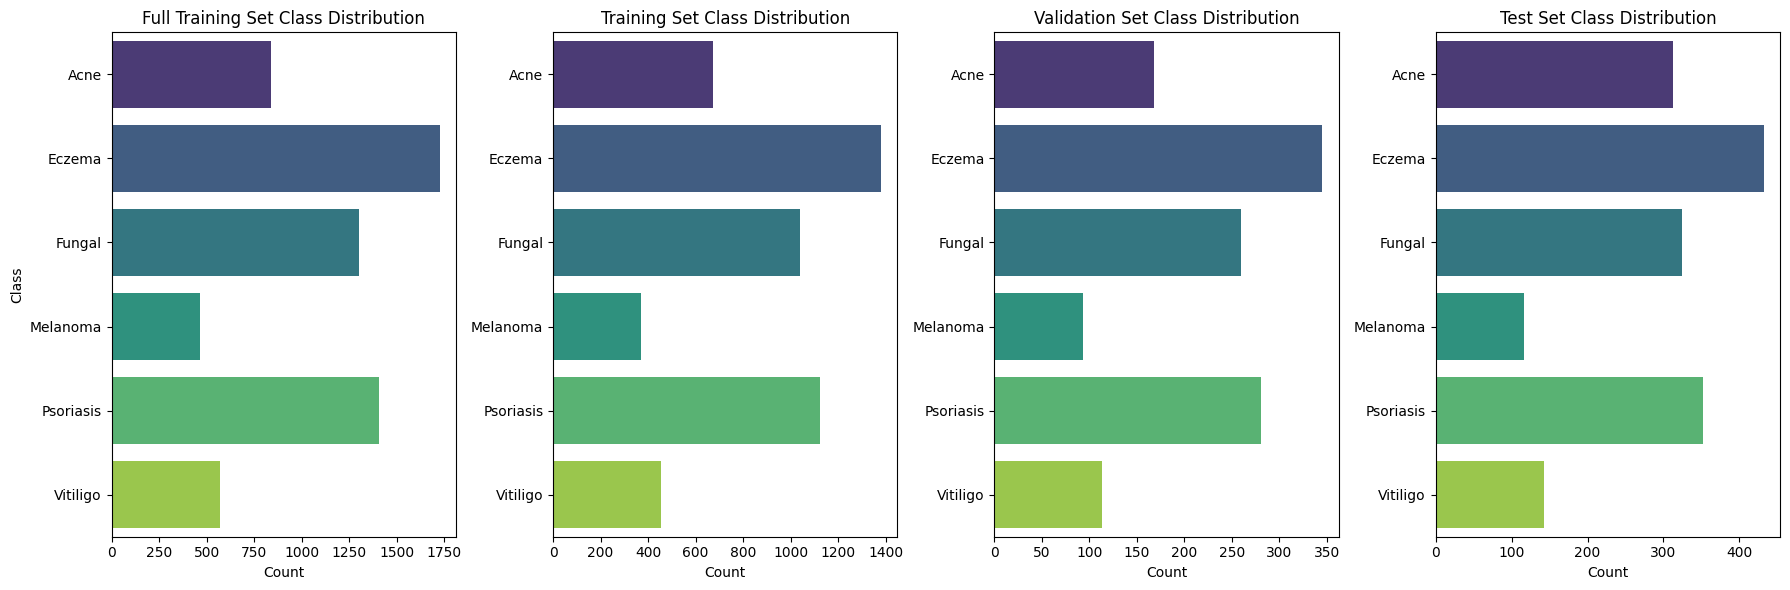

In [16]:
# Plot class distribution for full training, training, validation, and test sets
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
sns.countplot(y='class', data=df_train_full, order=class_names, palette='viridis')
plt.title('Full Training Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('Class')

plt.subplot(1, 4, 2)
sns.countplot(y='class', data=df_train, order=class_names, palette='viridis')
plt.title('Training Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('')

plt.subplot(1, 4, 3)
sns.countplot(y='class', data=df_val, order=class_names, palette='viridis')
plt.title('Validation Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('')

plt.subplot(1, 4, 4)
sns.countplot(y='class', data=df_test, order=class_names, palette='viridis')
plt.title('Test Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('')

plt.tight_layout()
plt.show()

### Sample Images per Class

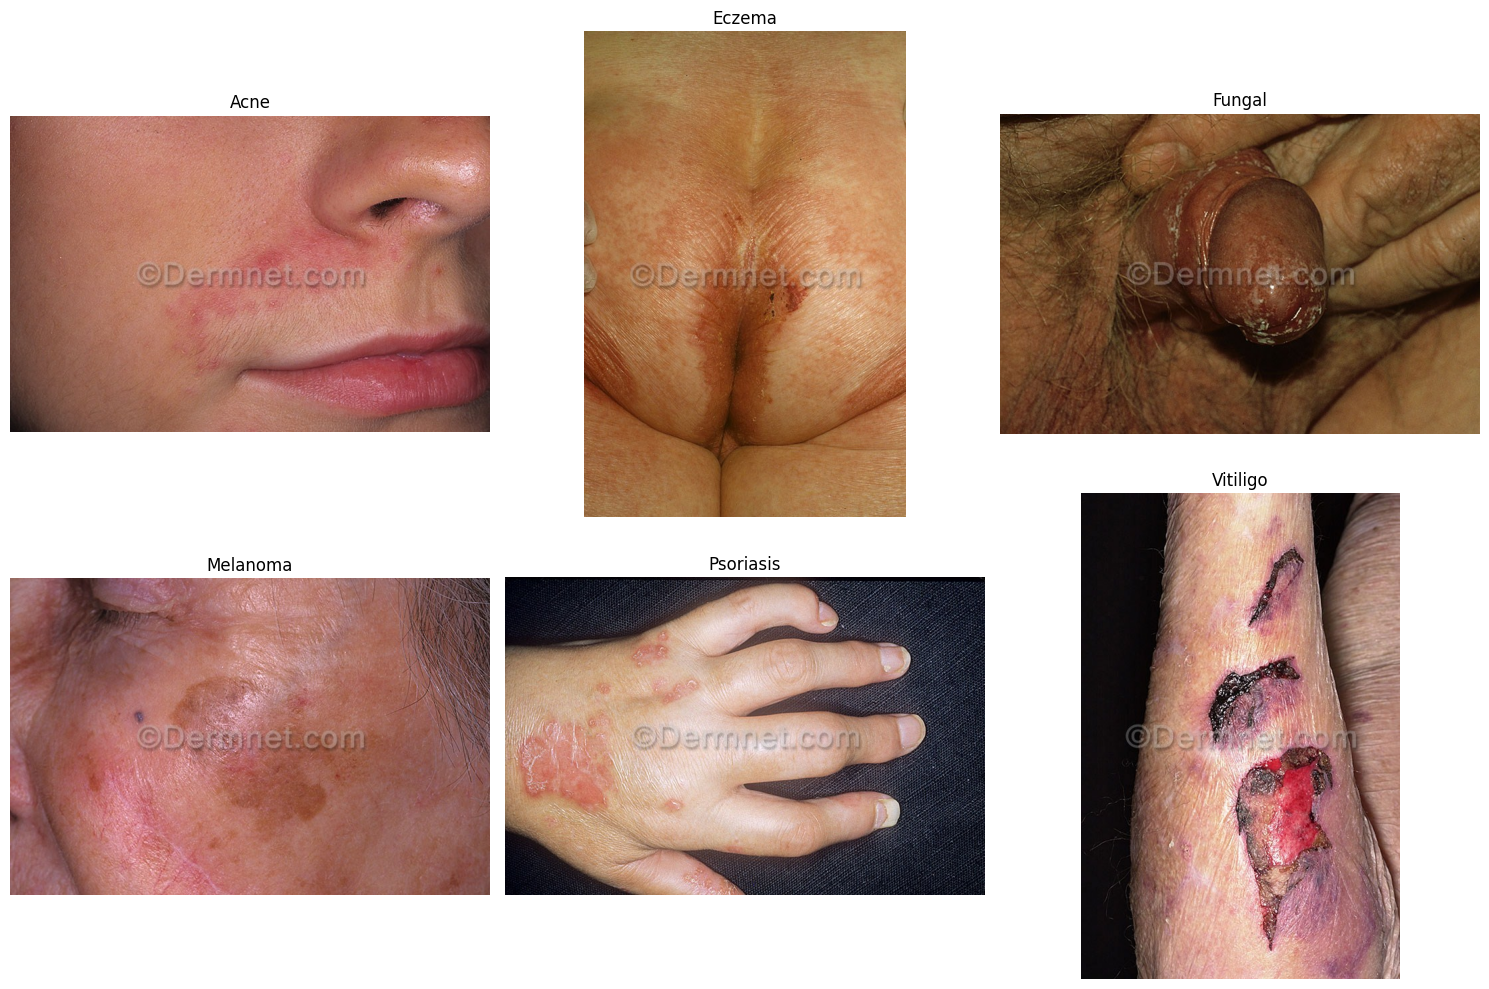

In [17]:
# Display a sample image for each class
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(class_names):
    plt.subplot(2, 3, i + 1)
    # Get a random image path for the current class from the training set
    sample_img_path = df_train[df_train['class'] == class_name].sample(1)['filename'].iloc[0]
    full_img_path = os.path.join(TRAIN_DIR, sample_img_path)
    img = Image.open(full_img_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

### Interpreting Class Distribution

From the generated plots, it's evident that there's a significant class imbalance across the dataset. Some classes like 'Eczema' and 'Fungal' have a much larger number of samples compared to 'Melanoma' and 'Vitiligo'. This imbalance is consistent across the full training, training, validation, and test sets.

This is a critical observation, as imbalanced datasets can lead to models that perform well on majority classes but poorly on minority classes. The model might become biased towards the more frequent classes, resulting in lower recall and F1-scores for the under-represented diseases.

### Quantifying Class Imbalance

To better understand the extent of this imbalance, let's calculate the exact counts and percentages for each class in the full training dataset.

In [21]:
print('Class Distribution in Full Training Set:')
class_counts = df_train_full['class'].value_counts()
class_percentages = df_train_full['class'].value_counts(normalize=True) * 100

class_distribution_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
}).sort_values(by='Count', ascending=False)

display(class_distribution_df)


Class Distribution in Full Training Set:


,Count,Percentage
class,,
Eczema,1724,27.365079
Psoriasis,1405,22.301587
Fungal,1300,20.634921
Acne,840,13.333333
Vitiligo,568,9.015873
Melanoma,463,7.349206


### Dataset Problems and Solutions

**Identified Problem: Class Imbalance**

The numerical breakdown clearly shows that 'Psoriasis', 'Eczema', and 'Fungal' are the majority classes, while 'Melanoma' and 'Vitiligo' are significantly under-represented. This imbalance can severely impact the model's ability to accurately predict minority classes.

**Potential Solutions:**

1.  **Resampling Techniques:**
    *   **Oversampling minority classes:** Duplicating samples from minority classes (e.g., using `ImageDataGenerator`'s `rotation_range`, `zoom_range` to create new variations, or techniques like SMOTE).
    *   **Undersampling majority classes:** Randomly removing samples from majority classes (use with caution to avoid losing valuable information).
2.  **Class Weighting:** As already implemented, assigning higher weights to minority classes during training helps the model pay more attention to their errors. This was done using `compute_class_weight`.
3.  **Data Augmentation:** While already in use, more aggressive augmentation for minority classes can help create more diverse samples.
4.  **Evaluation Metrics:** Focus on metrics like F1-score, precision, recall, and AUC-ROC, especially per-class, rather than just overall accuracy, as accuracy can be misleading on imbalanced datasets.

## 3. Training & Architecture

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg19 import preprocess_input, VGG19
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

class_names = sorted(df_train['class'].unique())

print("Balancing training dataset using oversampling to improve macro F1 score...")
# Balance df_train by oversampling minority classes to match the size of the largest class
max_class_size = df_train['class'].value_counts().max()
balanced_dfs = []
for c in class_names:
    df_c = df_train[df_train['class'] == c]
    if len(df_c) < max_class_size:
        df_c = df_c.sample(max_class_size, replace=True, random_state=42)
    balanced_dfs.append(df_c)
df_train_balanced = pd.concat(balanced_dfs, axis=0).sample(frac=1.0, random_state=42).reset_index(drop=True)

print(f"Original df_train size: {len(df_train)}")
print(f"Balanced df_train size: {len(df_train_balanced)}")
print("Class Distribution for Training:")
print(df_train_balanced['class'].value_counts())

# Generators with proper VGG19 preprocessing_function (preprocess_input)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(df_train_balanced, directory=TRAIN_DIR, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_test_datagen.flow_from_dataframe(df_val, directory=TRAIN_DIR, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen = val_test_datagen.flow_from_dataframe(df_test, directory=TEST_DIR, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# Re-architect classifier head with GlobalAveragePooling and an optimized dense block
vgg = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg.trainable = False

x = GlobalAveragePooling2D()(vgg.output)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
out = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=vgg.input, outputs=out)
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    ModelCheckpoint('best_skin_model.h5', save_best_only=True, monitor='val_accuracy'),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

print("\n--- Training Phase 1: Classification Head ---")
model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=callbacks)

print("\n--- Training Phase 2: Fine-Tuning ---")
vgg.trainable = True
for layer in vgg.layers[:-5]:
    layer.trainable = False

model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=callbacks)


Addressing class imbalance using data augmentation and class weights (no explicit dataset duplication).
Original df_train size: 5040
Original Class Distribution for Training (used for class weights):
class
Eczema       1379
Psoriasis    1124
Fungal       1040
Acne          672
Vitiligo      455
Melanoma      370
Name: count, dtype: int64
Found 5040 validated image filenames belonging to 6 classes.
Found 1260 validated image filenames belonging to 6 classes.
Found 1680 validated image filenames belonging to 6 classes.

--- Training Phase 1: Classification Head ---
Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.2231 - loss: 3.1241

158/158 ━━━━━━━━━━━━━━━━━━━━ 81s 476ms/step - accuracy: 0.2401 - loss: 2.8938 - val_accuracy: 0.2429 - val_loss: 2.2020 - learning_rate: 0.0010
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.2701 - loss: 2.4941

158/158 ━━━━━━━━━━━━━━━━━━━━ 70s 442ms/step - accuracy: 0.2796 - loss: 2.4469 - val_accuracy: 0.2857 - val_loss: 2.1047 - learning_rate: 0.0010
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.2879 - loss: 2.3081

158/158 ━━━━━━━━━━━━━━━━━━━━ 69s 440ms/step - accuracy: 0.2952 - loss: 2.2492 - val_accuracy: 0.3556 - val_loss: 2.0829 - learning_rate: 0.0010
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 70s 441ms/step - accuracy: 0.3177 - loss: 2.1063 - val_accuracy: 0.3484 - val_loss: 2.0363 - learning_rate: 0.0010
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.3231 - loss: 2.0305

158/158 ━━━━━━━━━━━━━━━━━━━━ 70s 443ms/step - accuracy: 0.3244 - loss: 2.0163 - val_accuracy: 0.3667 - val_loss: 1.9334 - learning_rate: 0.0010
Epoch 6/50
149/158 ━━━━━━━━━━━━━━━━━━━━ 3s 397ms/step - accuracy: 0.3346 - loss: 1.9632

## 4. Evaluation

53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 260ms/step

Classification Report:
              precision    recall  f1-score   support

        Acne       0.62      0.79      0.70       312
      Eczema       0.59      0.53      0.56       432
      Fungal       0.53      0.41      0.47       325
    Melanoma       0.49      0.76      0.60       116
   Psoriasis       0.50      0.35      0.41       352
    Vitiligo       0.35      0.55      0.43       143

    accuracy                           0.53      1680
   macro avg       0.52      0.56      0.53      1680
weighted avg       0.54      0.53      0.53      1680



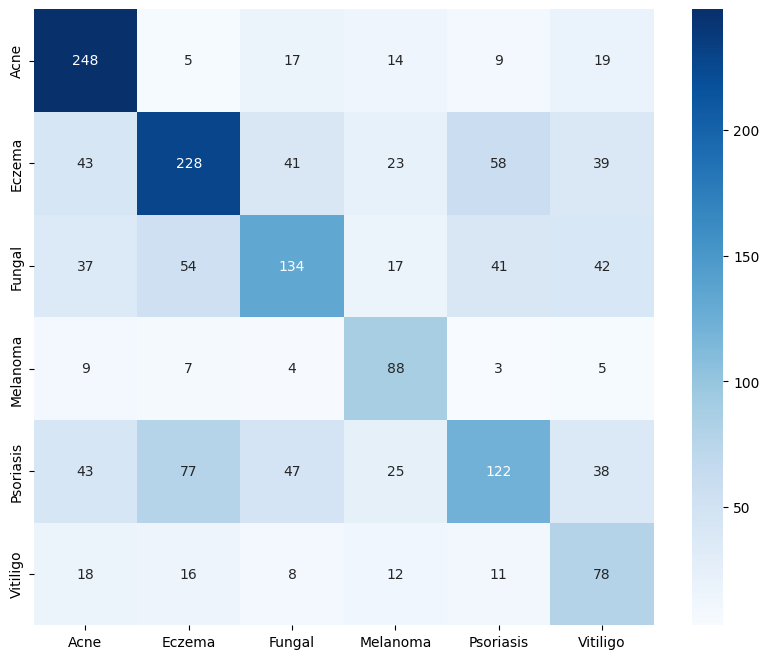

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.show()